# Import statements

In [1]:
import sys
sys.path.append("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork")

from IPython.display import display, HTML, Markdown
import murraylab_tools.echo as mt_echo
import os.path
import pandas as pd
from murraylab_tools.echo.echo_functions import echo_round
import os.path
import math

import matplotlib.pyplot as plt

import os

import numpy as np

import itertools

import seaborn as sns


In [2]:
test_df = pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20251105_Arul_Tuning_Redo/inputs/96_to_384_df.csv")

# let's randomize the rows 
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

test_df.to_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20251105_Arul_Tuning_Redo/inputs/96_to_384_df_randomized.csv", index=False)

In [3]:
# get the working directory
os.getcwd()

'/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20251105_Arul_Tuning_Redo'

In [4]:
INPUT_DIR = os.path.join(os.getcwd(), "inputs")

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")

# create the output directory if it does not exist
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

if not os.path.exists(INPUT_DIR):
    os.makedirs(INPUT_DIR)

In [5]:
sa_correct = {"6-well": 1,
              "24-well":0.2,
              "48-well": 0.088,
              "96-well": 0.32/9.6,}


well_map = pd.read_csv(os.path.join(INPUT_DIR, "96_to_384_df.csv"))

plate1_wells = well_map[well_map["96_plate"] == "Plate 1"]["384_well"].tolist()
plate2_wells = well_map[well_map["96_plate"] == "Plate 2"]["384_well"].tolist()
plate3_wells = well_map[well_map["96_plate"] == "Plate 3"]["384_well"].tolist()
plate4_wells = well_map[well_map["96_plate"] == "Plate 4"]["384_well"].tolist()

materials_df = pd.read_csv(os.path.join(INPUT_DIR, "material_definitions.csv"))

size_dict = materials_df.set_index("material")["size_bp"].to_dict()

mw_dict = dict([(mid, size_dict[mid] * 0.650 / 1000) for mid in size_dict])  # in ng/fmol

In [6]:
mw_dict

{'m567_GvpA': 2.977,
 'm163_GvpF': 3.3202000000000003,
 'm164_GvpG': 3.08685,
 'm165_GvpJ': 3.3260500000000004,
 'm166_GvpK': 3.1447000000000003,
 'm167_GvpN': 3.4957000000000003,
 'm168_GvpV': 3.0699500000000004,
 'm169_GvpW': 3.28315,
 'puc19': 1.7459}

In [7]:
# Different gvpA ratios to test (12x)
gvpa_ratio_list = [(12)]

# fmol basis to test where the value in the list is defined as 1x
fmol_1x_list = [50]


negative_ratio = [((0, 0, 0, 0, 0, 0, 0), 0, 50)] # negative control
base_positive_ratio = [((0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), 12, 50)] # base positive control
positive_ratio  = [((1, 1, 1, 1, 1, 1, 1), 12, 50)] # high positive control

hail_mary_ratios = [((1, 0.25, 0.25, 1, 2, 0, 1), 12, 50),
                    ((1, 1.5, 0.125, 1.5, 1.5, 0, 1.5), 12, 50),
                    ((1, 1, 0.125, 2, 2, 0, 1), 12, 50),
                    ((0.5, 1.5, 0.125, 1.5, 1.5, 0, 1), 12, 50),
                    ]


chaperone_order_letters = ["N", "J", "K", "F", "G", "V", "W"]

chaperone_order = ["m167_GvpN", "m165_GvpJ", "m166_GvpK", "m163_GvpF", "m164_GvpG", "m168_GvpV", "m169_GvpW"]

chaperone_ratio_list = (list(set(list(itertools.permutations([1, 1, 1, 1, 1, 1, 0])))) + # delete a chaperone
                        list(set(list(itertools.permutations([1, 1, 1, 1, 1, 1, 0.25])))) + # decrease one chaperone by 4x
                        list(set(list(itertools.permutations([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1])))) + # increase one chaperone by 4x
                        list(set(list(itertools.permutations([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 2])))) + # increase one chaperone by 8x
                        list(set(list(itertools.permutations([0.25, 0.25, 0.25, 0.25, 0.25, 1, 1])))) + # increase two chaperones by 4x
                        list(set(list(itertools.permutations([0.25, 0.25, 0.25, 0.25, 1, 1, 1]))))  # increase three chaperone by 4x
)


combo_list = list(itertools.product(chaperone_ratio_list, gvpa_ratio_list, fmol_1x_list)) 

combo_list = (combo_list + 
              negative_ratio + negative_ratio + 
              base_positive_ratio + base_positive_ratio + base_positive_ratio +
              positive_ratio + positive_ratio + positive_ratio +
              hail_mary_ratios 

)

len(combo_list)




96

In [8]:
combo_list

[((1, 1, 1, 1, 1, 1, 0), 12, 50),
 ((1, 0, 1, 1, 1, 1, 1), 12, 50),
 ((1, 1, 1, 1, 1, 0, 1), 12, 50),
 ((1, 1, 0, 1, 1, 1, 1), 12, 50),
 ((1, 1, 1, 1, 0, 1, 1), 12, 50),
 ((0, 1, 1, 1, 1, 1, 1), 12, 50),
 ((1, 1, 1, 0, 1, 1, 1), 12, 50),
 ((0.25, 1, 1, 1, 1, 1, 1), 12, 50),
 ((1, 0.25, 1, 1, 1, 1, 1), 12, 50),
 ((1, 1, 1, 1, 1, 1, 0.25), 12, 50),
 ((1, 1, 1, 1, 1, 0.25, 1), 12, 50),
 ((1, 1, 1, 1, 0.25, 1, 1), 12, 50),
 ((1, 1, 0.25, 1, 1, 1, 1), 12, 50),
 ((1, 1, 1, 0.25, 1, 1, 1), 12, 50),
 ((0.25, 1, 0.25, 0.25, 0.25, 0.25, 0.25), 12, 50),
 ((0.25, 0.25, 0.25, 0.25, 0.25, 1, 0.25), 12, 50),
 ((0.25, 0.25, 1, 0.25, 0.25, 0.25, 0.25), 12, 50),
 ((0.25, 0.25, 0.25, 0.25, 1, 0.25, 0.25), 12, 50),
 ((1, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25), 12, 50),
 ((0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 1), 12, 50),
 ((0.25, 0.25, 0.25, 1, 0.25, 0.25, 0.25), 12, 50),
 ((0.25, 0.25, 0.25, 0.25, 2, 0.25, 0.25), 12, 50),
 ((0.25, 2, 0.25, 0.25, 0.25, 0.25, 0.25), 12, 50),
 ((2, 0.25, 0.25, 0.25, 0.25, 0.25,

In [9]:
gvpa_fmol_list = []
chap_fmol_list = []
line_items = []
name_list = []
meta_line_items = []


for combo in combo_list:
    fmol_basis = combo[-1]
    gvpa_ratio = combo[-2]
    if len(combo[0]) != len(chaperone_order):
        raise ValueError("Chaperone ratio length does not match chaperone order length")

    gvpa_fmol = gvpa_ratio * fmol_basis
    chaperone_fmol_list = [x * fmol_basis for x in combo[0]]

    gvpa_fmol_list.append(gvpa_fmol)
    chap_fmol_list.append(sum(chaperone_fmol_list)/len(chaperone_fmol_list))

    combo_dict = dict(zip(chaperone_order, chaperone_fmol_list))
    combo_dict["m567_GvpA"] = gvpa_fmol

    combo_name = f"{fmol_basis}fmol_{gvpa_ratio}xA_" + "".join([f"{combo[0][i]}x{chaperone_order_letters[i]}_" for i in range(len(chaperone_order_letters))])

    meta_dict = dict(zip(chaperone_order, combo[0]))
    meta_dict["avg_chap_ratio"] = sum(combo[0])/ len(combo[0])
    meta_dict["m567_GvpA"] = gvpa_ratio
    meta_dict["fmol_1x"] = fmol_basis
    meta_dict["combo_name"] = combo_name

    line_items.append(combo_dict)

    meta_line_items.append(meta_dict)

# repeat the number of times you want each combo to be replicated (here 4)    
fmol_df = pd.DataFrame(line_items + line_items + line_items + line_items)
meta_df = pd.DataFrame(meta_line_items+meta_line_items+meta_line_items + meta_line_items)



In [10]:
vol_basis = 4 # uL

# Number of replicates, here we have already put the replicates into the 96-well format, so just do repl=2 for extra volume
repl = 2

line_items = []
for index, row in fmol_df.iterrows():
    
    corr_factor = repl * sa_correct["96-well"]
    
    puc19_ng = 3000 * corr_factor - sum([ row[mid] * mw_dict[mid] * corr_factor for mid in row.to_dict()])
    puc19_nM = puc19_ng/mw_dict["puc19"]/vol_basis # nM fmol/uL = nM
    

    nm_dict = dict([(mid, row[mid] * corr_factor / vol_basis)  for mid in row.to_dict()])
    nm_dict["puc19"] = puc19_nM
    nm_dict["neg_flag"] = 0 if puc19_ng >= 0 else 1

    line_items.append(nm_dict)

nM_df = pd.DataFrame(line_items)

columns_order = []
for idx, col in enumerate(nM_df.drop(columns=["neg_flag"]).columns, start=1):
    nM_df = nM_df.rename(columns={col: f"concentration(nM).{idx}"})
    nM_df[f"component_{idx}"] = col

    columns_order.append(f"component_{idx}")
    columns_order.append(f"concentration(nM).{idx}")

columns_order.append("neg_flag")
nM_df = nM_df[columns_order]

In [11]:
combo_df = pd.concat([meta_df, nM_df], axis=1)

combo_df["fmol_A"] = combo_df["fmol_1x"] * combo_df["m567_GvpA"]
combo_df["fmol_avg_chap"] = combo_df["fmol_1x"] * combo_df["avg_chap_ratio"]
combo_df["A_chap_ratio"] = combo_df["fmol_A"] / combo_df["fmol_avg_chap"]

combo_df.head()

,m167_GvpN,m165_GvpJ,m166_GvpK,m163_GvpF,m164_GvpG,m168_GvpV,m169_GvpW,avg_chap_ratio,m567_GvpA,fmol_1x,...,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9,neg_flag,fmol_A,fmol_avg_chap,A_chap_ratio
0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.857143,12,50,...,m169_GvpW,0.000000,m567_GvpA,10.0,puc19,2.306618,0,600,42.857143,14.0
1,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.857143,12,50,...,m169_GvpW,0.833333,m567_GvpA,10.0,puc19,2.327095,0,600,42.857143,14.0
2,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.857143,12,50,...,m169_GvpW,0.833333,m567_GvpA,10.0,puc19,2.204856,0,600,42.857143,14.0
3,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.857143,12,50,...,m169_GvpW,0.833333,m567_GvpA,10.0,puc19,2.240535,0,600,42.857143,14.0
4,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.857143,12,50,...,m169_GvpW,0.833333,m567_GvpA,10.0,puc19,2.212923,0,600,42.857143,14.0


In [12]:
print(len(combo_df[combo_df["neg_flag"] == 0]))
print(len(combo_df[combo_df["neg_flag"] == 1]))
error_df = combo_df[combo_df["neg_flag"] ==1 ]

error_df.groupby("fmol_1x").size().reset_index(name='counts')

384
0


,fmol_1x,counts


In [13]:
error_df.groupby(["fmol_1x", "m567_GvpA", "avg_chap_ratio", "combo_name"]).size().reset_index(name='counts').head()

,fmol_1x,m567_GvpA,avg_chap_ratio,combo_name,counts


In [14]:
positive_control_items = combo_df[(combo_df["fmol_1x"] == 50) & (combo_df["fmol_A"] == 600) & (combo_df["avg_chap_ratio"].round(2) == 1)]

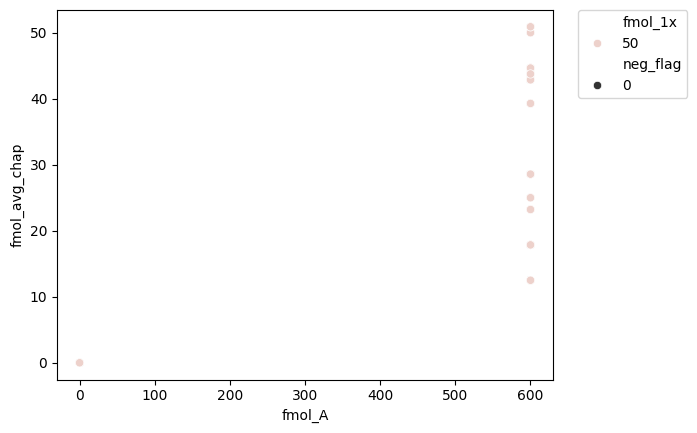

In [15]:
sns.scatterplot(data=combo_df, x="fmol_A", y="fmol_avg_chap", hue="fmol_1x", style="neg_flag")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

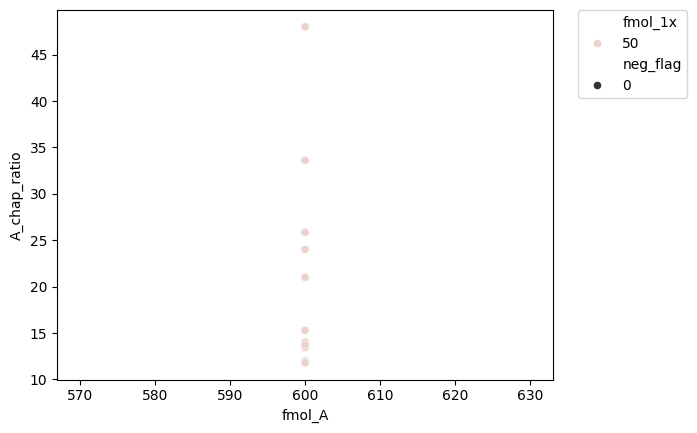

In [16]:
sns.scatterplot(data=combo_df, x="fmol_A", y="A_chap_ratio", hue="fmol_1x", style="neg_flag")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [17]:
combo_df.groupby("combo_name").size().reset_index(name='counts').sort_values(by='counts', ascending=False)["combo_name"].tolist()

combo_df_no_controls = combo_df[~combo_df["combo_name"].isin([ '50fmol_12xA_0.25xN_0.25xJ_0.25xK_0.25xF_0.25xG_0.25xV_0.25xW_',
                                                             '50fmol_12xA_1xN_1xJ_1xK_1xF_1xG_1xV_1xW_',
                                                            '50fmol_0xA_0xN_0xJ_0xK_0xF_0xG_0xV_0xW_' ])].reset_index(drop=True)

combo_df_no_controls = combo_df_no_controls.sort_values(by = "combo_name").reset_index(drop=True)

base_positive_line_item = combo_df[combo_df["combo_name"] == "50fmol_12xA_0.25xN_0.25xJ_0.25xK_0.25xF_0.25xG_0.25xV_0.25xW_"].reset_index(drop=True).iloc[0:3, :]
positive_line_item = combo_df[combo_df["combo_name"] == '50fmol_12xA_1xN_1xJ_1xK_1xF_1xG_1xV_1xW_'].reset_index(drop=True).iloc[0:3, :]

# we are going to hard code in C8 as a negative control well because of pipetting errors in the robot
negative_line_item = combo_df[combo_df["combo_name"] == '50fmol_0xA_0xN_0xJ_0xK_0xF_0xG_0xV_0xW_'].reset_index(drop=True).iloc[0:1, :]

In [18]:
# we want 22 sets of 4 replicates in each plate. These should not include the positive controls or negative controls

In [19]:
# so the first offset will have 96 wells, 88 line items + 3 positive controls + 3 base positive controls + 2 negative controls = 96 wells

# but we always want the C8 well to be the negative control because of pipetting errors in the robot


In [20]:
well_map[well_map["96_well"] == "C8"]

c8_well_384 = well_map[well_map["96_well"] == "C8"]["384_well"].values

c8_well_384

array(['E15', 'E16', 'F15', 'F16'], dtype=object)

In [21]:
well_map[well_map["96_well"] == "C8"]

,384_id,384_well,96_well,96_plate
110,111,E15,C8,Plate 1
111,112,E16,C8,Plate 2
134,135,F15,C8,Plate 3
135,136,F16,C8,Plate 4


In [22]:
all_picks_df_list = []
all_picks_df_extended_cols = []

for idx, plate in enumerate([plate1_wells, plate2_wells, plate3_wells, plate4_wells]):
   # take the first 88 items from combo_df_no_controls
   picks_df = combo_df_no_controls.iloc[idx*88:(idx+1)*88, :].reset_index(drop=True)
   
   # to avoid modifying the original plate list
   plate = list(plate)

   # append 3 positive controls, 3 base positive controls, and 1 negative control
   append_positive_control = pd.concat([positive_line_item, base_positive_line_item, negative_line_item], axis=0).reset_index(drop=True)
   picks_df = pd.concat([picks_df, append_positive_control], axis=0).reset_index(drop=True)
   print(len(picks_df))

   random_seed = 42 + idx  # Different seed for each plate
   print(len(plate))
   plate.remove(c8_well_384[idx])  # remove C8 well from the plate wells
   print(len(plate))
   # randomize the picks_df in the plate
   picks_df = picks_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

   
   # assign a well to each line item in the picks_df
   picks_df.loc[:, "well_id"] = plate[:len(picks_df)]
   picks_df["Plate"] = "Plate " + str(idx + 1)
   
   # add back in a C8 well as negative control
   c8_item = negative_line_item.copy()
   c8_item.loc[:, "well_id"] = c8_well_384[idx]
   c8_item["Plate"] = "Plate " + str(idx + 1)
   picks_df = pd.concat([picks_df, c8_item], axis=0).reset_index(drop=True)

   picks_df = picks_df.copy()
   print(len(picks_df))
   for col in picks_df.columns:
      if col.startswith("component_"):
         # skip the columns with m567_GvpA
         if "m567_GvpA" in picks_df.loc[:, col].values[0]:
            continue
         # skip the puc19 column
         if "puc19" in picks_df.loc[:, col].values[0]:
            continue
         picks_df.loc[:,col] = picks_df.loc[:, col] + "_" + str(50) + "fmol"
 
   all_picks_df_extended_cols.append(picks_df.copy())

   picks_df = picks_df[["well_id"] + columns_order].drop(columns=["neg_flag"])

   all_picks_df_list.append(picks_df)


95
96
95
96
95
96
95
96
95
96
95
96
95
96
95
96


In [32]:
all_picks_df = pd.concat(all_picks_df_list, axis=0).reset_index(drop=True)

all_picks_df


all_picks_df[all_picks_df["well_id"].isin(c8_well_384)]

,well_id,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,component_5,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9
95,E15,m167_GvpN_50fmol,0.0,m165_GvpJ_50fmol,0.0,m166_GvpK_50fmol,0.0,m163_GvpF_50fmol,0.0,m164_GvpG_50fmol,0.0,m168_GvpV_50fmol,0.0,m169_GvpW_50fmol,0.0,m567_GvpA,0.0,puc19,28.638525
191,E16,m167_GvpN_50fmol,0.0,m165_GvpJ_50fmol,0.0,m166_GvpK_50fmol,0.0,m163_GvpF_50fmol,0.0,m164_GvpG_50fmol,0.0,m168_GvpV_50fmol,0.0,m169_GvpW_50fmol,0.0,m567_GvpA,0.0,puc19,28.638525
287,F15,m167_GvpN_50fmol,0.0,m165_GvpJ_50fmol,0.0,m166_GvpK_50fmol,0.0,m163_GvpF_50fmol,0.0,m164_GvpG_50fmol,0.0,m168_GvpV_50fmol,0.0,m169_GvpW_50fmol,0.0,m567_GvpA,0.0,puc19,28.638525
383,F16,m167_GvpN_50fmol,0.0,m165_GvpJ_50fmol,0.0,m166_GvpK_50fmol,0.0,m163_GvpF_50fmol,0.0,m164_GvpG_50fmol,0.0,m168_GvpV_50fmol,0.0,m169_GvpW_50fmol,0.0,m567_GvpA,0.0,puc19,28.638525


In [ ]:
all_picks_df["f"]

In [30]:
all_picks_extended = pd.concat(all_picks_df_extended_cols, axis=0).reset_index(drop=True)
all_picks_extended.groupby(["combo_name", "Plate"]).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

all_picks_extended[all_picks_extended["combo_name"] == '50fmol_0xA_0xN_0xJ_0xK_0xF_0xG_0xV_0xW_']

all_picks_extended[all_picks_extended["well_id"].isin(c8_well_384)]

,m167_GvpN,m165_GvpJ,m166_GvpK,m163_GvpF,m164_GvpG,m168_GvpV,m169_GvpW,avg_chap_ratio,m567_GvpA,fmol_1x,...,component_8,concentration(nM).8,component_9,concentration(nM).9,neg_flag,fmol_A,fmol_avg_chap,A_chap_ratio,well_id,Plate
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,50,...,m567_GvpA,0.0,puc19,28.638525,0,0,0.0,NaN,E15,Plate 1
191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,50,...,m567_GvpA,0.0,puc19,28.638525,0,0,0.0,NaN,E16,Plate 2
287,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,50,...,m567_GvpA,0.0,puc19,28.638525,0,0,0.0,NaN,F15,Plate 3
383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,50,...,m567_GvpA,0.0,puc19,28.638525,0,0,0.0,NaN,F16,Plate 4


In [31]:
all_picks_df.to_csv(os.path.join(os.getcwd(),"inputs", "all_picks_1x_association.csv"), index=False)

all_picks_extended.to_csv(os.path.join(os.getcwd(),"inputs", "all_picks_1x_association_extended.csv"), index=False)
